# Un robot le ganó 3 de 5 partidos a jugadores de élite en tenis de mesa

**3 de 5.** Eso es lo que un robot de Sony llamado **Ace** consiguió contra cinco jugadores élite en abril de 2025 — bajo reglas oficiales de la ITTF, con paletas comerciales, sin ajustes. Luego lo pusieron contra dos profesionales y perdió los dos partidos.

¿Qué separa a un élite de un profesional? Los datos están ahí — 4.024 eventos grabados en 99 rallies. Abrámoslos.

---

**Paper:** D'Ambrosio et al. (2026). *Outplaying elite table tennis players with an autonomous robot*. **Nature**.
[DOI: 10.1038/s41586-026-10338-5](https://doi.org/10.1038/s41586-026-10338-5)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-24-robot-tenis-mesa-elite/notebook.ipynb)

*Video:* [Pendiente]

## Qué midieron

Ace es un sistema robótico de Sony: dos brazos KUKA, cámaras de alta velocidad y un controlador entrenado con aprendizaje por refuerzo. En abril de 2025 jugó contra siete humanos — cinco élite de club amateur y dos profesionales japoneses (Minami Ando y Kakeru Sone).

Cada rally quedó registrado como una secuencia de eventos: golpes, rebotes y redes. Para cada evento, el sistema registra posición, velocidad y efecto (spin) de la pelota en 3D. El dataset tiene **4.024 eventos** en total — **1.953 golpes**, 2.020 rebotes y 51 redes, distribuidos en 99 rallies.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
UMBRAL_ACE_VELOCIDAD = 13.32  # m/s — p95 de velocidad de Ace (paper: "up to 14 consistently")
UMBRAL_ACE_SPIN = 449         # rad/s — p95 de spin de Ace (paper: ">75% return up to 450")
FUENTE = 'Fuente: D\'Ambrosio et al. (2026), Nature | Datos: SonyResearch/ace_public'
COLOR_ACE = '#2563EB'         # Azul CaM — datos del robot
COLOR_HUMANO = '#DC2626'      # Rojo CaM — datos humanos
COLOR_ELITE = '#059669'       # Emerald — élite
COLOR_PRO = '#7C3AED'         # Violeta — profesionales
COLOR_UMBRAL = '#D97706'      # Amber — referencia/umbral

# ══════════════════════════════════════════════════════════════
# Setup
# ══════════════════════════════════════════════════════════════
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cargar estilo CaM (local primero, fallback a GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# ══════════════════════════════════════════════════════════════
# Carga de datos
# ══════════════════════════════════════════════════════════════
shots = pd.read_csv('datos/shots_clean.csv')

print(f"Golpes registrados: {len(shots):,}")
print(f"  — de Ace:      {(shots['shooter']=='Ace').sum():,}")
print(f"  — de humanos:  {(shots['shooter']=='Human').sum():,}")
print(f"Jugadores humanos: {shots[shots['shooter']=='Human']['player_id'].nunique()}")
print(f"  — élite: {shots[(shots['shooter']=='Human') & (shots['category']=='Elite')]['player_id'].nunique()}")
print(f"  — pros:  {shots[(shots['shooter']=='Human') & (shots['category']=='Pro')]['player_id'].nunique()}")
print(f"Rallies únicos: {shots['game_rally'].nunique()}")

Golpes registrados: 1,953
  — de Ace:      970
  — de humanos:  983
Jugadores humanos: 7
  — élite: 5
  — pros:  2
Rallies únicos: 99


## El resultado

Antes de meternos con la velocidad de la pelota o la física del spin, el marcador.

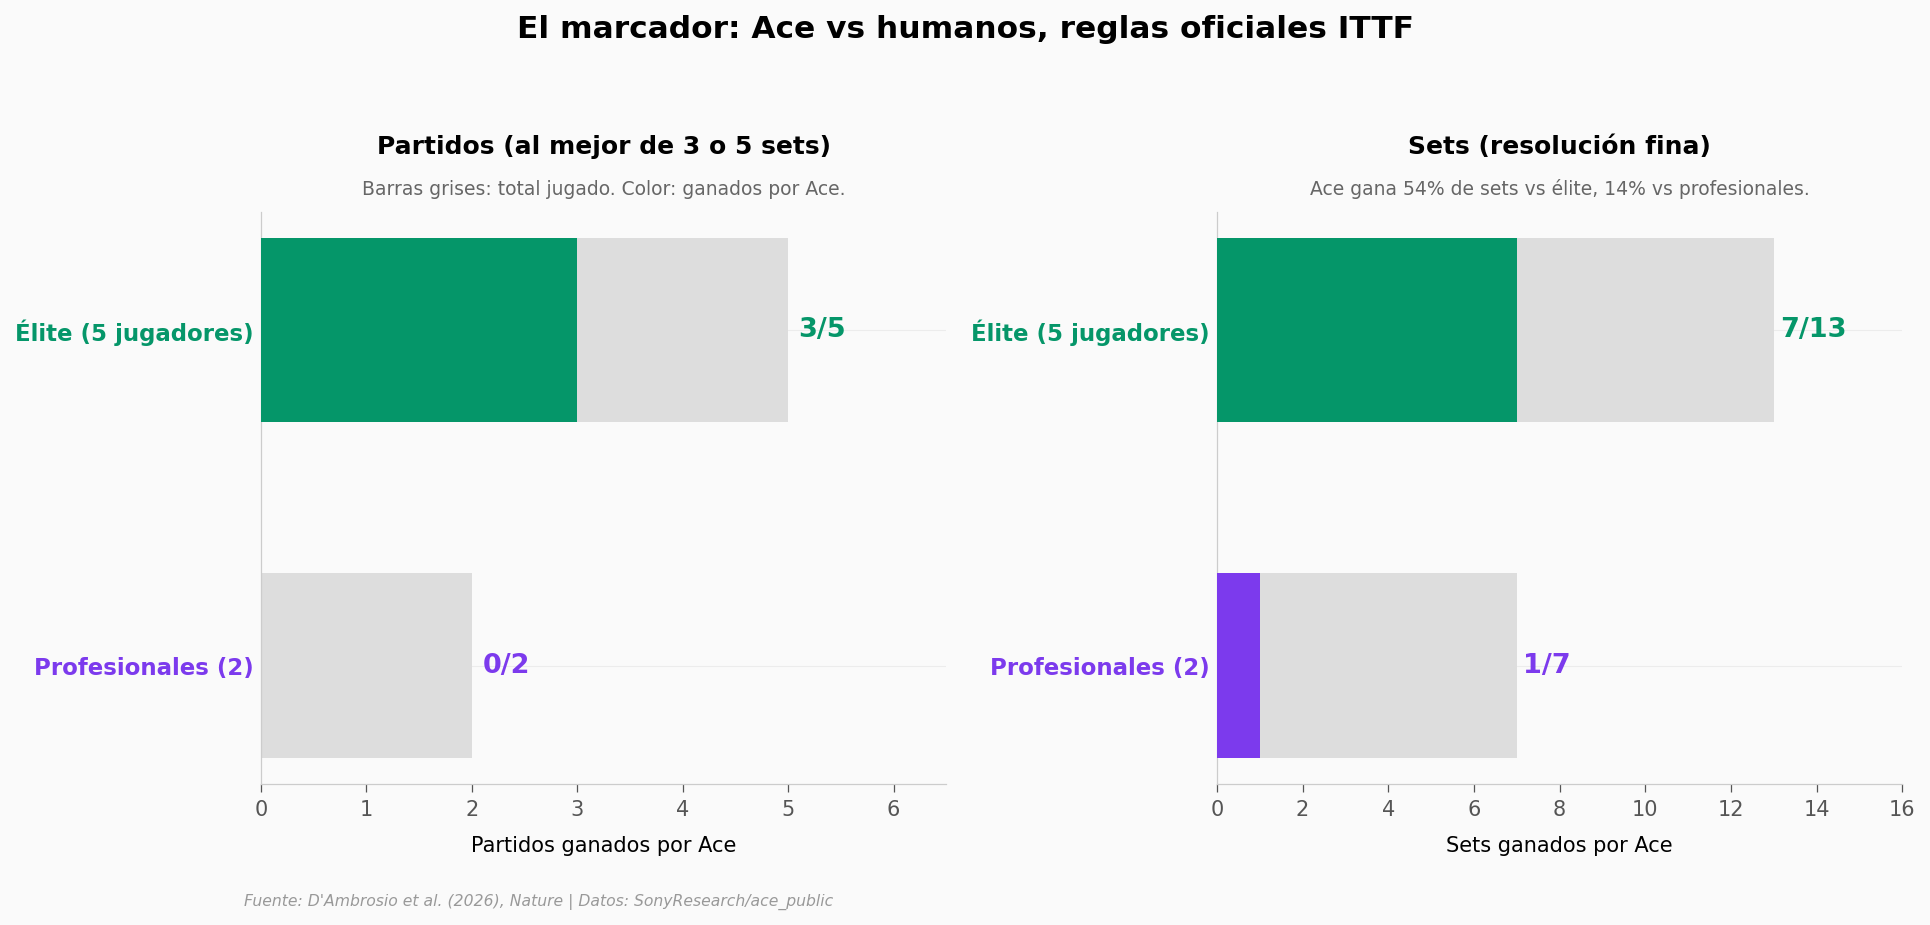

In [2]:
# Resultados oficiales del paper (Results section, Fig. 3a)
# NO se derivan de shots_clean.csv — son el conteo oficial de partidos/sets
results = pd.DataFrame({
    'categoria':      ['Élite (5 jugadores)', 'Profesionales (2)'],
    'matches_ganados': [3, 0],
    'matches_total':   [5, 2],
    'games_ganados':   [7, 1],
    'games_total':     [13, 7],
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# Subplot 1: Partidos (matches)
positions = [0, 1]
for i, row in results.iterrows():
    color = COLOR_ELITE if i == 0 else COLOR_PRO
    # Barra total (fondo gris claro)
    ax1.barh(positions[i], row['matches_total'], color='#DDDDDD',
             height=0.55, zorder=2)
    # Barra ganados (color)
    ax1.barh(positions[i], row['matches_ganados'], color=color,
             height=0.55, zorder=3)
    # Etiqueta a la derecha
    ax1.text(row['matches_total'] + 0.1, positions[i],
             f"{row['matches_ganados']}/{row['matches_total']}",
             fontsize=13, fontweight='bold', va='center', color=color)

ax1.set_yticks(positions)
ax1.set_yticklabels(results['categoria'], fontsize=11)
for tick, color in zip(ax1.get_yticklabels(), [COLOR_ELITE, COLOR_PRO]):
    tick.set_color(color)
    tick.set_fontweight('bold')
ax1.set_xlabel('Partidos ganados por Ace', fontsize=10)
ax1.set_xlim(0, 6.5)
ax1.set_title('Partidos (al mejor de 3 o 5 sets)', fontsize=12,
              fontweight='bold', pad=28)
ax1.text(0.5, 1.03, 'Barras grises: total jugado. Color: ganados por Ace.',
         transform=ax1.transAxes, fontsize=9, color='#666666', ha='center')
ax1.invert_yaxis()

# Subplot 2: Sets (games)
for i, row in results.iterrows():
    color = COLOR_ELITE if i == 0 else COLOR_PRO
    ax2.barh(positions[i], row['games_total'], color='#DDDDDD',
             height=0.55, zorder=2)
    ax2.barh(positions[i], row['games_ganados'], color=color,
             height=0.55, zorder=3)
    ax2.text(row['games_total'] + 0.15, positions[i],
             f"{row['games_ganados']}/{row['games_total']}",
             fontsize=13, fontweight='bold', va='center', color=color)

ax2.set_yticks(positions)
ax2.set_yticklabels(results['categoria'], fontsize=11)
for tick, color in zip(ax2.get_yticklabels(), [COLOR_ELITE, COLOR_PRO]):
    tick.set_color(color)
    tick.set_fontweight('bold')
ax2.set_xlabel('Sets ganados por Ace', fontsize=10)
ax2.set_xlim(0, 16)
ax2.set_title('Sets (resolución fina)', fontsize=12,
              fontweight='bold', pad=28)
ax2.text(0.5, 1.03, 'Ace gana 54% de sets vs élite, 14% vs profesionales.',
         transform=ax2.transAxes, fontsize=9, color='#666666', ha='center')
ax2.invert_yaxis()

fig.suptitle('El marcador: Ace vs humanos, reglas oficiales ITTF',
             fontsize=15, fontweight='bold', y=1.05)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/01_resultados_torneo.png', dpi=200, bbox_inches='tight')
plt.show()

La diferencia entre los dos grupos es enorme. Contra élite el robot compite — gana más partidos de los que pierde. Contra profesionales el marcador cambia de régimen: de 7 sets jugados solo consigue 1.

Entre un élite de club y un profesional japonés hay un salto que Ace no cruza. Veamos dónde aparece esa brecha en los datos de la pelota.

## ¿A qué velocidad pega cada uno?

Cada golpe del dataset trae el vector de velocidad de la pelota justo después del impacto — lo que el oponente tiene que devolver. La magnitud de ese vector es la velocidad del golpe, en metros por segundo.

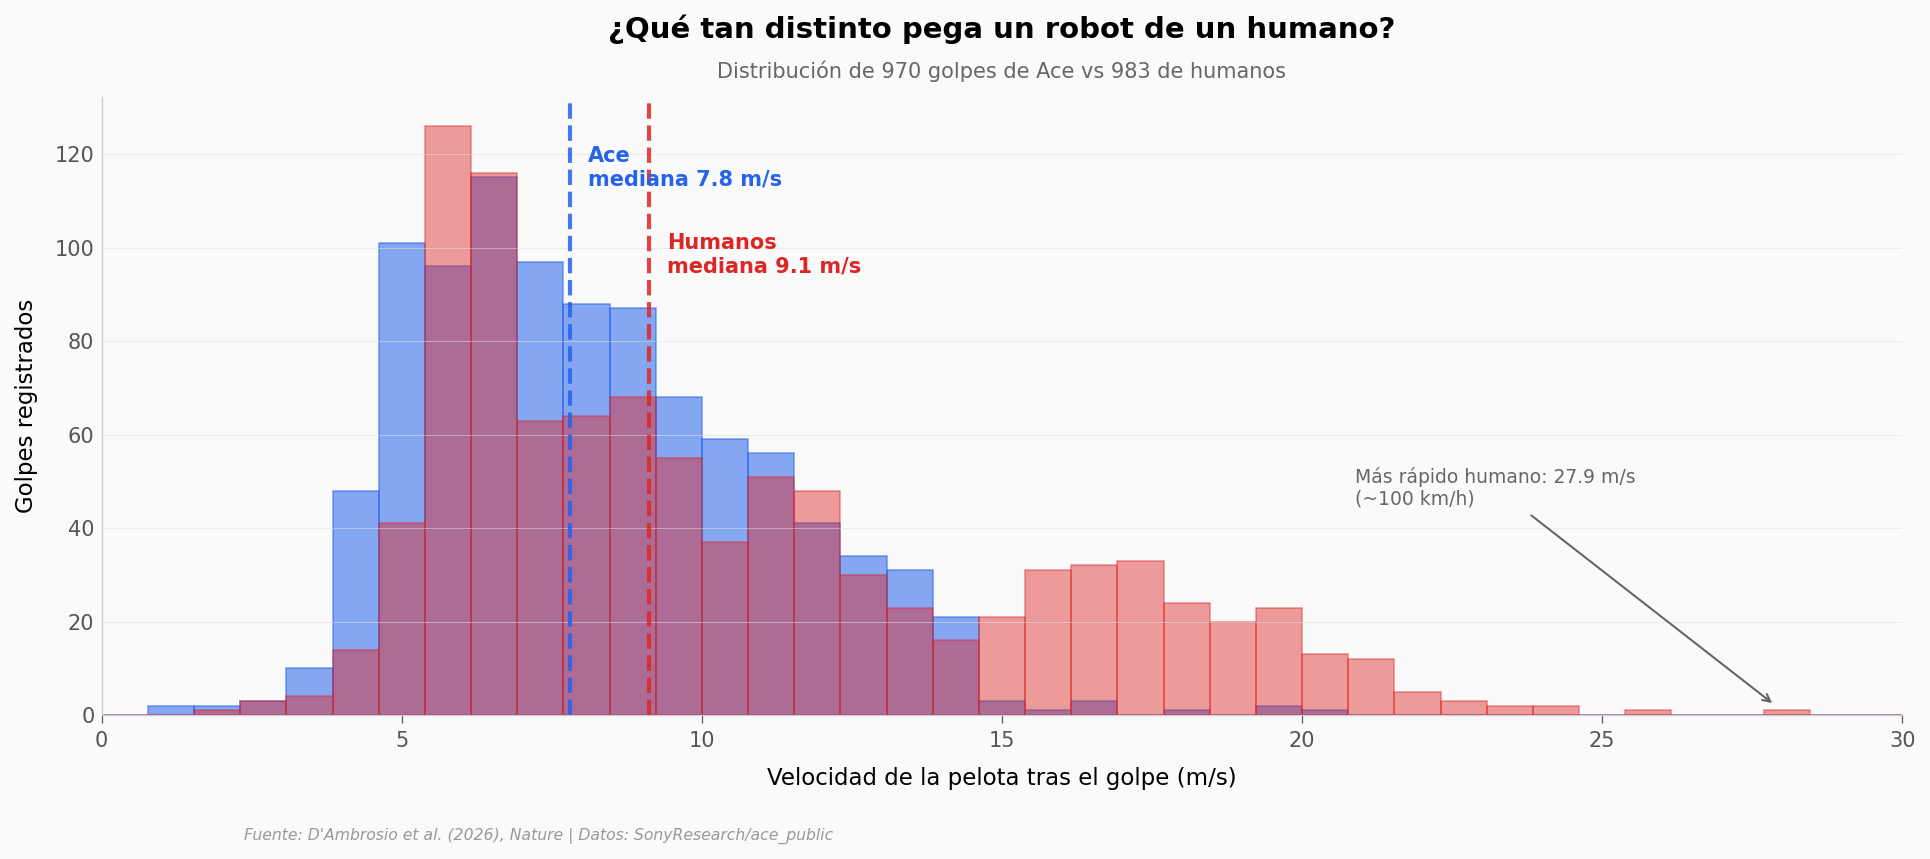

Mann-Whitney p-value: 6.41e-23
Cohen's d (pooled, independiente): 0.587 — efecto medio (0,5-0,8)
p95 Ace: 13.32 m/s — el paper declara 'hasta 14 m/s consistently'


In [3]:
# Separar golpes por quién pegó
v_ace = shots.loc[shots['shooter']=='Ace', 'speed'].values
v_hum = shots.loc[shots['shooter']=='Human', 'speed'].values

# Stats para anotación (coinciden con el Fact Sheet)
med_ace, med_hum = np.median(v_ace), np.median(v_hum)
p95_ace, p95_hum = np.percentile(v_ace, 95), np.percentile(v_hum, 95)
max_ace, max_hum = v_ace.max(), v_hum.max()

fig, ax = plt.subplots(figsize=(13, 5.5))

# Histograma superpuesto (mismo binning para comparabilidad)
bins = np.linspace(0, 30, 40)
ax.hist(v_ace, bins=bins, color=COLOR_ACE, alpha=0.55,
        edgecolor=COLOR_ACE, linewidth=0.8, label='_nolegend_')
ax.hist(v_hum, bins=bins, color=COLOR_HUMANO, alpha=0.45,
        edgecolor=COLOR_HUMANO, linewidth=0.8, label='_nolegend_')

# Líneas de mediana
ax.axvline(med_ace, color=COLOR_ACE, linewidth=2, linestyle='--', alpha=0.85)
ax.axvline(med_hum, color=COLOR_HUMANO, linewidth=2, linestyle='--', alpha=0.85)

# Inline labels (reemplazan legend box)
ax.text(med_ace + 0.3, ax.get_ylim()[1]*0.92, f'Ace\nmediana {med_ace:.1f} m/s',
        fontsize=10, color=COLOR_ACE, fontweight='bold', va='top')
ax.text(med_hum + 0.3, ax.get_ylim()[1]*0.78, f'Humanos\nmediana {med_hum:.1f} m/s',
        fontsize=10, color=COLOR_HUMANO, fontweight='bold', va='top')

# Anotación del golpe más rápido humano
ax.annotate(f'Más rápido humano: {max_hum:.1f} m/s\n(~100 km/h)',
            xy=(max_hum, 2), xytext=(max_hum - 7, 45),
            fontsize=9, color='#666666',
            arrowprops=dict(arrowstyle='->', color='#666666', lw=1))

ax.set_xlabel('Velocidad de la pelota tras el golpe (m/s)', fontsize=11)
ax.set_ylabel('Golpes registrados', fontsize=11)
ax.set_title('¿Qué tan distinto pega un robot de un humano?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'Distribución de {len(v_ace):,} golpes de Ace vs {len(v_hum):,} de humanos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(0, 30)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/02_velocidad_histograma.png', dpi=200, bbox_inches='tight')
plt.show()

# Cross-check: Mann-Whitney + Cohen's d (reporta lo que tiene el Fact Sheet)
from scipy import stats
u_stat, p_val = stats.mannwhitneyu(v_hum, v_ace, alternative='greater')
# Cohen's d pooled
s_pooled = np.sqrt(((len(v_hum)-1)*v_hum.var(ddof=1) +
                    (len(v_ace)-1)*v_ace.var(ddof=1)) /
                   (len(v_hum) + len(v_ace) - 2))
d_pooled = (v_hum.mean() - v_ace.mean()) / s_pooled
print(f"Mann-Whitney p-value: {p_val:.2e}")
print(f"Cohen's d (pooled, independiente): {d_pooled:.3f} — efecto medio (0,5-0,8)")
print(f"p95 Ace: {p95_ace:.2f} m/s — el paper declara 'hasta 14 m/s consistently'")

## Velocidad no es todo: también está el spin

En tenis de mesa, el efecto rotatorio de la pelota (el *spin*) es tan importante como la velocidad. Un top-spin potente hace que la pelota curve hacia abajo tras cruzar la red; un back-spin la frena. Un jugador experto usa ambos para mover al oponente y forzar errores.

El dataset tiene la velocidad angular de la pelota tras cada golpe — en radianes por segundo. Veamos cada golpe como un punto: velocidad en X, spin en Y.

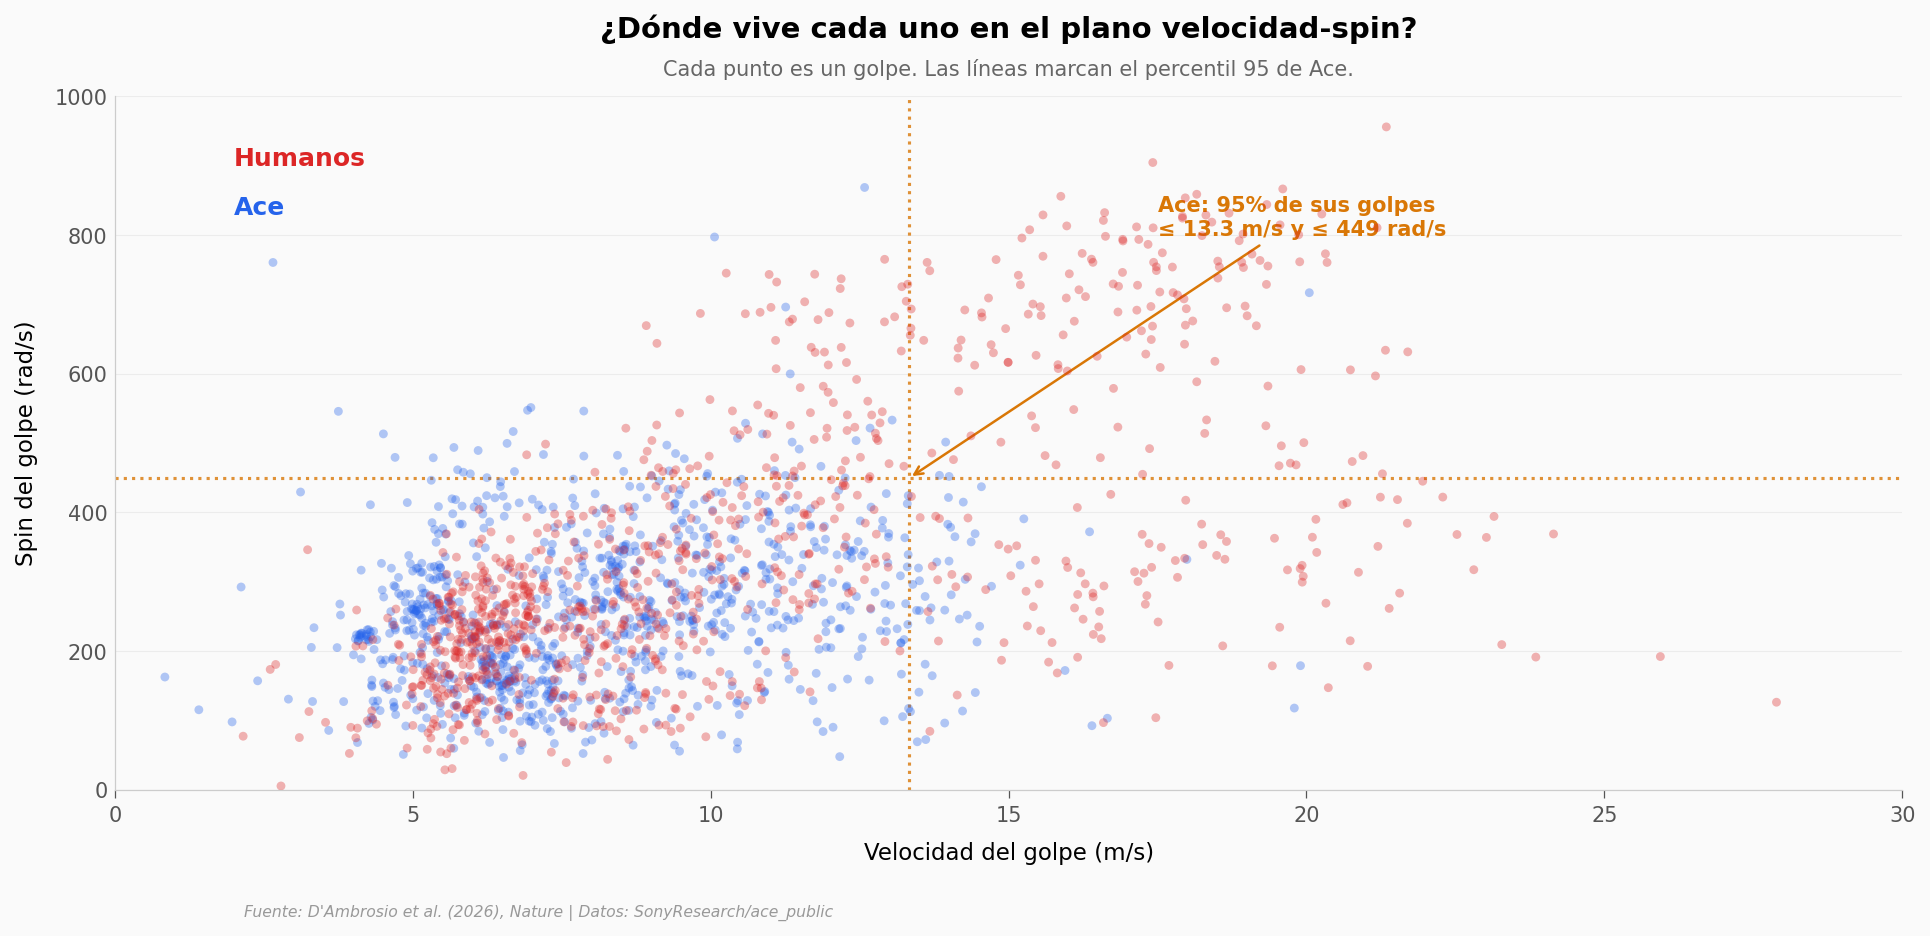

Ace: 95% de golpes ≤ 13.3 m/s y ≤ 449 rad/s
Humanos: p95 = 19.67 m/s y 754 rad/s


In [4]:
fig, ax = plt.subplots(figsize=(13, 6))

# Scatter Ace (primero, atrás)
ax.scatter(shots.loc[shots['shooter']=='Ace', 'speed'],
           shots.loc[shots['shooter']=='Ace', 'spin_mag'],
           color=COLOR_ACE, s=18, alpha=0.35,
           edgecolors='none', label='_nolegend_', zorder=3)
# Scatter humanos (al frente)
ax.scatter(shots.loc[shots['shooter']=='Human', 'speed'],
           shots.loc[shots['shooter']=='Human', 'spin_mag'],
           color=COLOR_HUMANO, s=18, alpha=0.35,
           edgecolors='none', label='_nolegend_', zorder=4)

# Líneas del p95 de Ace — el "techo operativo" declarado por el paper
ax.axvline(UMBRAL_ACE_VELOCIDAD, color=COLOR_UMBRAL, linewidth=1.5,
           linestyle=':', alpha=0.8, zorder=2)
ax.axhline(UMBRAL_ACE_SPIN, color=COLOR_UMBRAL, linewidth=1.5,
           linestyle=':', alpha=0.8, zorder=2)

# Anotación del techo
ax.annotate(f'Ace: 95% de sus golpes\n≤ {UMBRAL_ACE_VELOCIDAD:.1f} m/s y ≤ {UMBRAL_ACE_SPIN} rad/s',
            xy=(UMBRAL_ACE_VELOCIDAD, UMBRAL_ACE_SPIN),
            xytext=(17.5, 800),
            fontsize=10, color=COLOR_UMBRAL, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_UMBRAL, lw=1.2))

# Inline labels para grupos
ax.text(2, 900, 'Humanos', fontsize=12, color=COLOR_HUMANO, fontweight='bold')
ax.text(2, 830, 'Ace',     fontsize=12, color=COLOR_ACE,    fontweight='bold')

ax.set_xlabel('Velocidad del golpe (m/s)', fontsize=11)
ax.set_ylabel('Spin del golpe (rad/s)', fontsize=11)
ax.set_title('¿Dónde vive cada uno en el plano velocidad-spin?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Cada punto es un golpe. Las líneas marcan el percentil 95 de Ace.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(0, 30)
ax.set_ylim(0, 1000)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/03_velocidad_vs_spin.png', dpi=200, bbox_inches='tight')
plt.show()

# Reportar el techo operativo
print(f"Ace: 95% de golpes ≤ {UMBRAL_ACE_VELOCIDAD:.1f} m/s y ≤ {UMBRAL_ACE_SPIN} rad/s")
print(f"Humanos: p95 = {np.percentile(shots.loc[shots.shooter=='Human','speed'], 95):.2f} m/s "
      f"y {np.percentile(shots.loc[shots.shooter=='Human','spin_mag'], 95):.0f} rad/s")

## ¿Cuántos golpes humanos quedan fuera del alcance de Ace?

El paper lo declara en letras gruesas: Ace devuelve consistentemente golpes de hasta 14 m/s. Arriba de 16 empieza a fallar — igual que los humanos, eso sí.

Traduzcamos ese límite a la distribución humana: ¿qué fracción de los 983 golpes que pegaron los humanos en el torneo viven por encima del techo operativo de Ace?

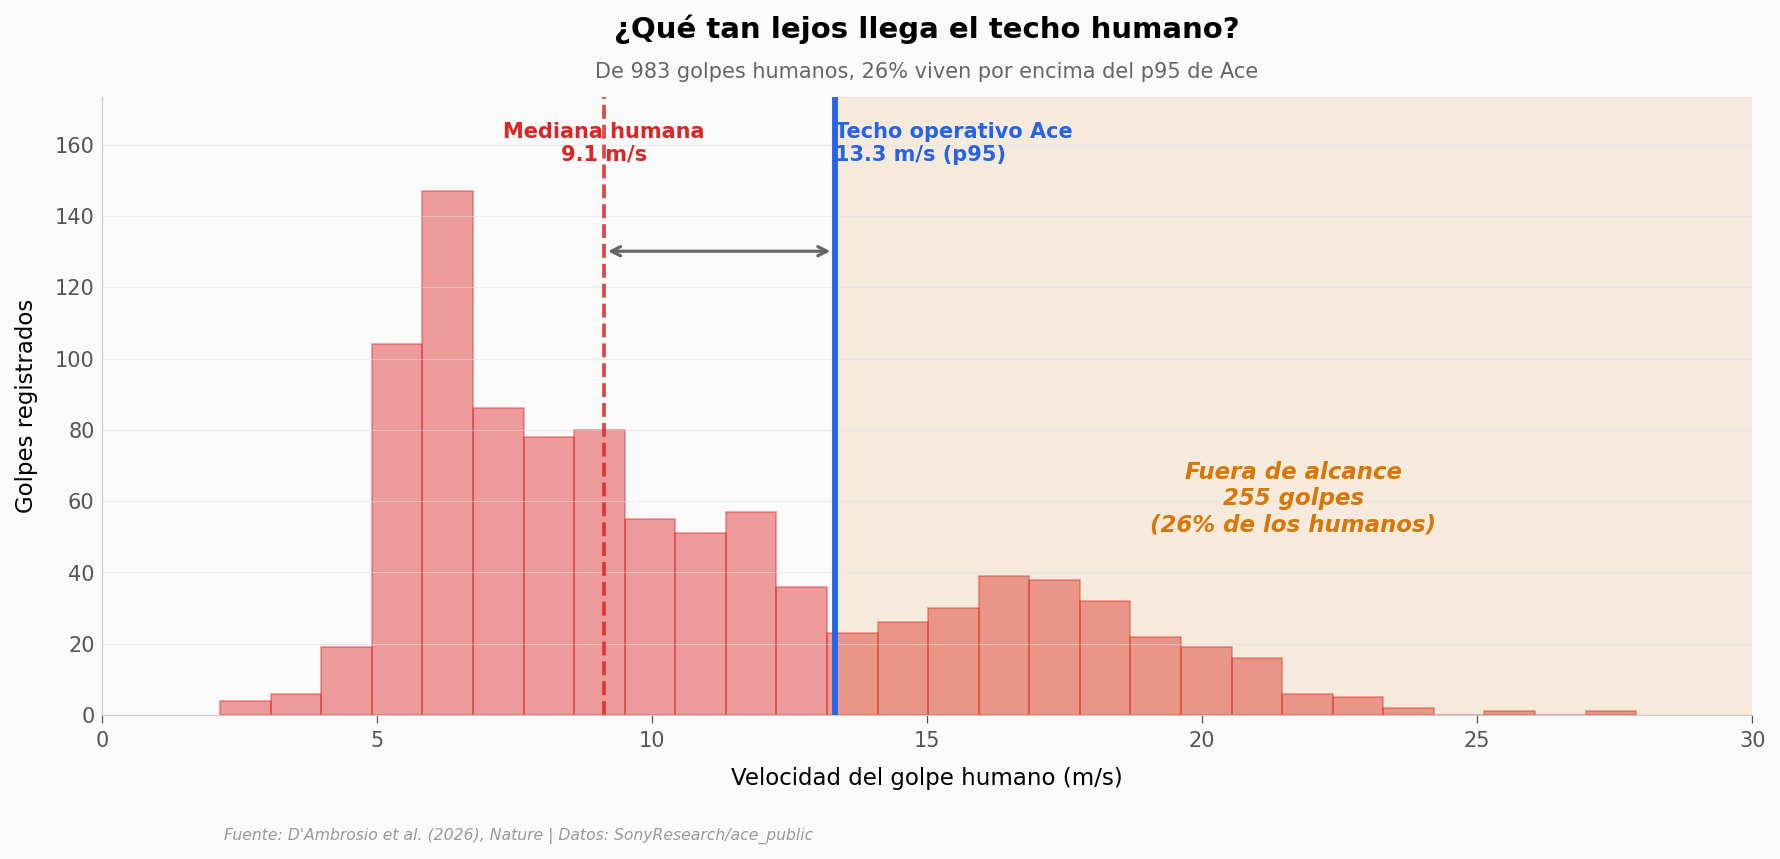

Golpes humanos por encima del p95 de Ace: 255 de 983 (25.9%)
Golpe humano más rápido: 27.9 m/s


In [5]:
fig, ax = plt.subplots(figsize=(12, 5.5))

# Histograma de velocidades humanas
v_hum = shots.loc[shots['shooter']=='Human', 'speed'].values
n, bins, patches = ax.hist(v_hum, bins=28, color=COLOR_HUMANO, alpha=0.45,
                           edgecolor=COLOR_HUMANO, linewidth=0.8)
y_max = n.max() * 1.18
ax.set_ylim(0, y_max)

# Mediana humana
med_hum = np.median(v_hum)
ax.axvline(med_hum, color=COLOR_HUMANO, linewidth=1.8,
           linestyle='--', alpha=0.85)

# Techo de Ace — la línea que importa
ax.axvline(UMBRAL_ACE_VELOCIDAD, color=COLOR_ACE, linewidth=2.8, zorder=5)

# Flecha bidireccional — diferencia entre mediana humana y techo de Ace
y_flecha = y_max * 0.75
ax.annotate('', xy=(UMBRAL_ACE_VELOCIDAD, y_flecha),
            xytext=(med_hum, y_flecha),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))

# Calcular qué fracción humana supera el techo de Ace
frac_sobre = (v_hum > UMBRAL_ACE_VELOCIDAD).mean()
n_sobre = (v_hum > UMBRAL_ACE_VELOCIDAD).sum()

# Anotaciones
ax.text(med_hum, y_max*0.96,
        f'Mediana humana\n{med_hum:.1f} m/s',
        fontsize=10, color=COLOR_HUMANO, fontweight='bold',
        ha='center', va='top')
ax.text(UMBRAL_ACE_VELOCIDAD, y_max*0.96,
        f'Techo operativo Ace\n{UMBRAL_ACE_VELOCIDAD:.1f} m/s (p95)',
        fontsize=10, color=COLOR_ACE, fontweight='bold',
        ha='left', va='top')

# Zona "fuera de alcance" sombreada
ax.axvspan(UMBRAL_ACE_VELOCIDAD, 30, alpha=0.12, color=COLOR_UMBRAL, zorder=1)
ax.text((UMBRAL_ACE_VELOCIDAD + 30) / 2, y_max*0.35,
        f'Fuera de alcance\n{n_sobre} golpes\n({frac_sobre*100:.0f}% de los humanos)',
        fontsize=11, color=COLOR_UMBRAL, fontweight='bold',
        ha='center', va='center', style='italic')

ax.set_xlabel('Velocidad del golpe humano (m/s)', fontsize=11)
ax.set_ylabel('Golpes registrados', fontsize=11)
ax.set_title(f'¿Qué tan lejos llega el techo humano?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'De {len(v_hum):,} golpes humanos, {frac_sobre*100:.0f}% viven por encima del p95 de Ace',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(0, 30)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/04_techo_humano.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Golpes humanos por encima del p95 de Ace: {n_sobre} de {len(v_hum)} ({frac_sobre*100:.1f}%)")
print(f"Golpe humano más rápido: {v_hum.max():.1f} m/s")

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Ace ganó 3 de 5 partidos contra jugadores élite | ✅ | 7/13 sets. Fuente: Results section del paper |
| Ace perdió ambos partidos contra profesionales | ✅ | 1/7 sets. Fuente: Results section del paper |
| Humanos pegan más rápido que Ace (efecto medio) | ✅ | Mann-Whitney p = 6,4 × 10⁻²³, Cohen's d = 0,59 |
| Humanos producen más spin que Ace (efecto medio) | ✅ | Fact Sheet: Mann-Whitney p ≈ 2,0 × 10⁻¹⁶, Cohen's d = 0,53 |
| Ace devuelve consistentemente golpes hasta 14 m/s | ✅ | p95 de Ace = 13,3 m/s — coincide con el claim del paper |
| Ace cubre la mayor parte del juego humano | ⚠️ parcial | 74% de los golpes humanos viven ≤ 13,3 m/s; el 26% restante queda fuera del techo operativo de Ace |

**Limitaciones:**
- El dataset registra el estado de la pelota DESPUÉS del golpe, no el gesto del jugador. No tenemos posición del cuerpo ni tipo de grip.
- "Ganar un golpe" no es lo mismo que "devolverlo". El paper reporta tasa de retorno (>75% hasta 450 rad/s), no tasa de ganar el punto.
- Muestra pequeña: 5 élite + 2 pros. No se puede generalizar a "todos los profesionales del mundo".
- Los resultados son de un único tramo de testing (abril 2025). El paper no reporta longitudinal.

## Ahora tú

Cambia `UMBRAL_ACE_VELOCIDAD` en la celda de configuración al comienzo del notebook y re-ejecuta — puedes probar:

1. **¿Qué pasa si Ace fuera 2 m/s más rápido?** Cambia `UMBRAL_ACE_VELOCIDAD = 15.32` y vuelve a correr la celda 11. ¿Cuánto baja el % "fuera de alcance"?
2. **¿Cómo se distribuye la diferencia élite vs pro?** En la celda siguiente hay código para graficar el spin mediano por jugador.
3. **¿Hay rallies más largos contra pros?** La columna `game_rally` identifica cada rally. Prueba agrupando shots por rally y mirando la distribución de longitudes.

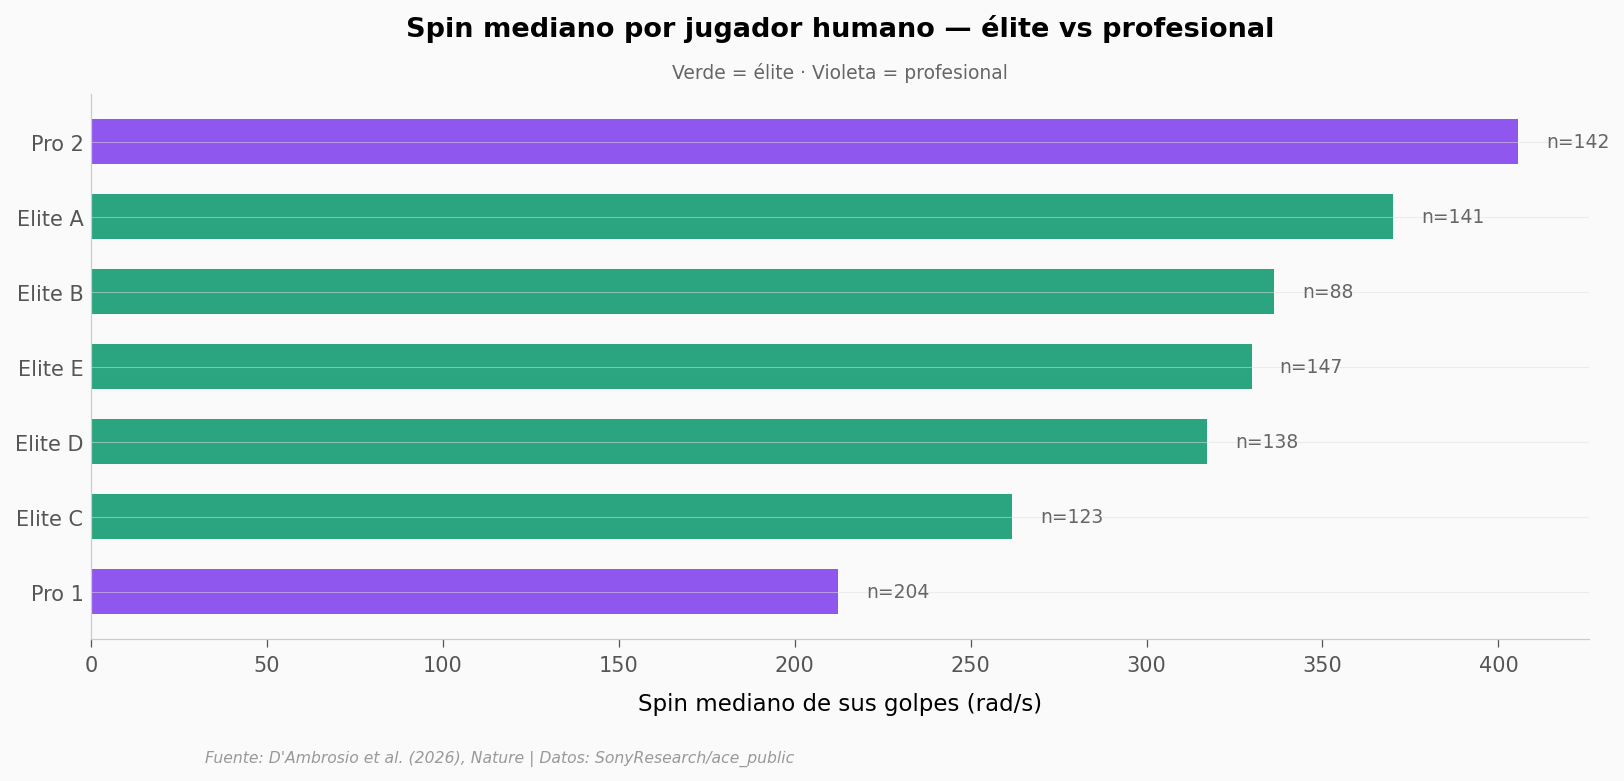

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Spin mediano por jugador — ¿quién usa más efecto?

per_player = (shots[shots['shooter']=='Human']
              .groupby(['category', 'player_id'])['spin_mag']
              .agg(['median', 'count'])
              .reset_index()
              .sort_values('median', ascending=True))

fig, ax = plt.subplots(figsize=(11, 5))
colors = [COLOR_PRO if c == 'Pro' else COLOR_ELITE for c in per_player['category']]
bars = ax.barh(range(len(per_player)), per_player['median'], color=colors,
               height=0.6, alpha=0.85)

# Etiqueta con count
for i, (med, n) in enumerate(zip(per_player['median'], per_player['count'])):
    ax.text(med + 8, i, f'n={n}', fontsize=9, color='#666666', va='center')

ax.set_yticks(range(len(per_player)))
ax.set_yticklabels(per_player['player_id'], fontsize=10)
ax.set_xlabel('Spin mediano de sus golpes (rad/s)', fontsize=11)
ax.set_title('Spin mediano por jugador humano — élite vs profesional',
             fontsize=13, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Verde = élite · Violeta = profesional',
        transform=ax.transAxes, fontsize=9, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/05_spin_por_jugador.png', dpi=200, bbox_inches='tight')
plt.show()

## Fuentes

**Paper**: [Outplaying elite table tennis players with an autonomous robot](https://doi.org/10.1038/s41586-026-10338-5)  
*Nature, 2026-04-22*

**Datos**: [Dataset: Outplaying Elite Table Tennis Players with an Autonomous Robot (match_data.csv)](https://github.com/SonyResearch/ace_public/blob/main/data/match_data.csv)

*19 afirmaciones verificadas contra estas fuentes*